# Import Libraries

In [54]:
import pandas as pd
import numpy as np
import re
import string

import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from sklearn.metrics import confusion_matrix, classification_report

[nltk_data] Downloading package punkt to /home/brian-maxwell-
[nltk_data]     ketaren/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/brian-maxwell-
[nltk_data]     ketaren/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


# Load Dataset

In [3]:
reviews = pd.read_csv('reviews.csv')

In [4]:
reviews.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,28f2c0bb-1a6f-46f4-9f4c-dd9b957db0c5,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Awal nya nyaman sekali tapi belakangan ini jd ...,4,12,2.62.1,2024-08-06 14:20:44,"Hi Kak Atha, maaf bikin kamu jadi gak nyaman. ...",2024-08-06 15:08:45,2.62.1
1,98682abf-84fe-45b7-b514-5ae38fe6595a,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Saya kadih bintang 5 biar di baca, Saya kira a...",5,912,2.61.1,2024-07-31 13:28:53,"Makasih buat review nya, kalo ada keluhan hubu...",2024-07-31 13:30:31,2.61.1
2,900d3629-8bbc-4f31-a546-fd700786bda1,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,(Sudah melakukan yang disarankan tapi gak ngar...,5,555,2.61.1,2024-08-02 19:59:19,"Hi Kak, maaf sdh bikin tdk tenang. Terkait kel...",2024-08-03 01:00:26,2.61.1
3,85e9d56b-a821-44f2-a4f1-89b25864881f,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Sebenarnya bagus bgt menggunakan apk ini, tapi...",4,1949,2.60.1,2024-07-24 00:39:00,"Makasih buat review nya, kalo ada keluhan hubu...",2024-07-24 00:40:33,2.60.1
4,d2d8d387-04d5-4911-b37c-55508766acff,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Untuk kirim/transfer antar rekening/nomor tuju...,1,108,2.61.1,2024-07-27 23:03:37,"Hi Kak Tedy, maaf udah bikin kecewa. Terkait k...",2024-07-28 01:06:59,2.61.1


In [5]:
reviews.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   reviewId              10000 non-null  str  
 1   userName              10000 non-null  str  
 2   userImage             10000 non-null  str  
 3   content               10000 non-null  str  
 4   score                 10000 non-null  int64
 5   thumbsUpCount         10000 non-null  int64
 6   reviewCreatedVersion  9981 non-null   str  
 7   at                    10000 non-null  str  
 8   replyContent          9945 non-null   str  
 9   repliedAt             9945 non-null   str  
 10  appVersion            9981 non-null   str  
dtypes: int64(2), str(9)
memory usage: 7.6 MB


In [6]:
clean_df = reviews.drop(columns=['replyContent', 'repliedAt'])

# Preprocessing Text

In [7]:
def cleaningText(text):
    text = re.sub(r'@[A-Za-z0-9]+', '', text) # menghapus mention
    text = re.sub(r'#[A-Za-z0-9]+', '', text) # menghapus hashtag
    text = re.sub(r'RT[\s]', '', text) # menghapus RT
    text = re.sub(r"http\S+", '', text) # menghapus link
    text = re.sub(r'[0-9]+', '', text) # menghapus angka
    text = re.sub(r'[^\w\s]', '', text) # menghapus karakter selain huruf dan angka
 
    text = text.replace('\n', ' ') # mengganti baris baru dengan spasi
    text = text.translate(str.maketrans('', '', string.punctuation)) # menghapus semua tanda baca
    text = text.strip(' ') # menghapus karakter spasi dari kiri dan kanan teks
    return text
 
def casefoldingText(text): # Mengubah semua karakter dalam teks menjadi huruf kecil
    text = text.lower()
    return text
 
def tokenizingText(text): # Memecah atau membagi string, teks menjadi daftar token
    text = word_tokenize(text)
    return text
 
def filteringText(text): # Menghapus stopwords dalam teks
    listStopwords = set(stopwords.words('indonesian'))
    listStopwords1 = set(stopwords.words('english'))
    listStopwords.update(listStopwords1)
    listStopwords.update(['iya','yaa','gak','nya','na','sih','ku',"di","ga","ya","gaa","loh","kah","woi","woii","woy"])
    filtered = []
    for txt in text:
        if txt not in listStopwords:
            filtered.append(txt)
    text = filtered
    return text
 
def stemmingText(text): # Mengurangi kata ke bentuk dasarnya yang menghilangkan imbuhan awalan dan akhiran atau ke akar kata
    # Membuat objek stemmer
    factory = StemmerFactory()
    stemmer = factory.create_stemmer()
 
    # Memecah teks menjadi daftar kata
    words = text.split()
 
    # Menerapkan stemming pada setiap kata dalam daftar
    stemmed_words = [stemmer.stem(word) for word in words]
 
    # Menggabungkan kata-kata yang telah distem
    stemmed_text = ' '.join(stemmed_words)
 
    return stemmed_text
 
def toSentence(list_words): # Mengubah daftar kata menjadi kalimat
    sentence = ' '.join(word for word in list_words)
    return sentence

In [8]:
slangwords = {"@": "di", "abis": "habis", "wtb": "beli", "masi": "masih", "wts": "jual", "wtt": "tukar", "bgt": "banget", "maks": "maksimal"}
def fix_slangwords(text):
    words = text.split()
    fixed_words = []
 
    for word in words:
        if word.lower() in slangwords:
            fixed_words.append(slangwords[word.lower()])
        else:
            fixed_words.append(word)
 
    fixed_text = ' '.join(fixed_words)
    return fixed_text

In [10]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /home/brian-maxwell-
[nltk_data]     ketaren/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [11]:
# Membersihkan teks dan menyimpannya di kolom 'text_clean'
clean_df['text_clean'] = clean_df['content'].apply(cleaningText)
 
# Mengubah huruf dalam teks menjadi huruf kecil dan menyimpannya di 'text_casefoldingText'
clean_df['text_casefoldingText'] = clean_df['text_clean'].apply(casefoldingText)
 
# Mengganti kata-kata slang dengan kata-kata standar dan menyimpannya di 'text_slangwords'
clean_df['text_slangwords'] = clean_df['text_casefoldingText'].apply(fix_slangwords)
 
# Memecah teks menjadi token (kata-kata) dan menyimpannya di 'text_tokenizingText'
clean_df['text_tokenizingText'] = clean_df['text_slangwords'].apply(tokenizingText)
 
# Menghapus kata-kata stop (kata-kata umum) dan menyimpannya di 'text_stopword'
clean_df['text_stopword'] = clean_df['text_tokenizingText'].apply(filteringText)
 
# Menggabungkan token-token menjadi kalimat dan menyimpannya di 'text_akhir'
clean_df['text_akhir'] = clean_df['text_stopword'].apply(toSentence)

# Labeling

In [12]:
import csv
import requests
from io import StringIO
 
# Membaca data kamus kata-kata positif dari GitHub
lexicon_positive = dict()
 
response = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_positive.csv')
# Mengirim permintaan HTTP untuk mendapatkan file CSV dari GitHub
 
if response.status_code == 200:
    # Jika permintaan berhasil
    reader = csv.reader(StringIO(response.text), delimiter=',')
    # Membaca teks respons sebagai file CSV menggunakan pembaca CSV dengan pemisah koma
 
    for row in reader:
        # Mengulangi setiap baris dalam file CSV
        lexicon_positive[row[0]] = int(row[1])
        # Menambahkan kata-kata positif dan skornya ke dalam kamus lexicon_positive
else:
    print("Failed to fetch positive lexicon data")
 
# Membaca data kamus kata-kata negatif dari GitHub
lexicon_negative = dict()
 
response = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_negative.csv')
# Mengirim permintaan HTTP untuk mendapatkan file CSV dari GitHub
 
if response.status_code == 200:
    # Jika permintaan berhasil
    reader = csv.reader(StringIO(response.text), delimiter=',')
    # Membaca teks respons sebagai file CSV menggunakan pembaca CSV dengan pemisah koma
 
    for row in reader:
        # Mengulangi setiap baris dalam file CSV
        lexicon_negative[row[0]] = int(row[1])
        # Menambahkan kata-kata negatif dan skornya dalam kamus lexicon_negative
else:
    print("Failed to fetch negative lexicon data")

In [13]:
# Fungsi untuk menentukan polaritas sentimen dari tweet
 
def sentiment_analysis_lexicon_indonesia(text):
    #for word in text:
 
    score = 0
    # Inisialisasi skor sentimen ke 0
 
    for word in text:
        # Mengulangi setiap kata dalam teks
 
        if (word in lexicon_positive):
            score = score + lexicon_positive[word]
            # Jika kata ada dalam kamus positif, tambahkan skornya ke skor sentimen
 
    for word in text:
        # Mengulangi setiap kata dalam teks (sekali lagi)
 
        if (word in lexicon_negative):
            score = score + lexicon_negative[word]
            # Jika kata ada dalam kamus negatif, kurangkan skornya dari skor sentimen
 
    polarity=''
    # Inisialisasi variabel polaritas
 

    if (score >= 0):
        polarity = 'positive'
    elif (score <= -7):
        polarity = 'negative'
    else:
        polarity = 'neutral'
 
    return score, polarity
    # Mengembalikan skor sentimen dan polaritas teks 
    

In [14]:
results = clean_df['text_stopword'].apply(sentiment_analysis_lexicon_indonesia)
results = list(zip(*results))
clean_df['polarity_score'] = results[0]
clean_df['polarity'] = results[1]
print(clean_df['polarity'].value_counts())

polarity
positive    5689
neutral     2450
negative    1861
Name: count, dtype: int64


In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

<Axes: xlabel='polarity', ylabel='count'>

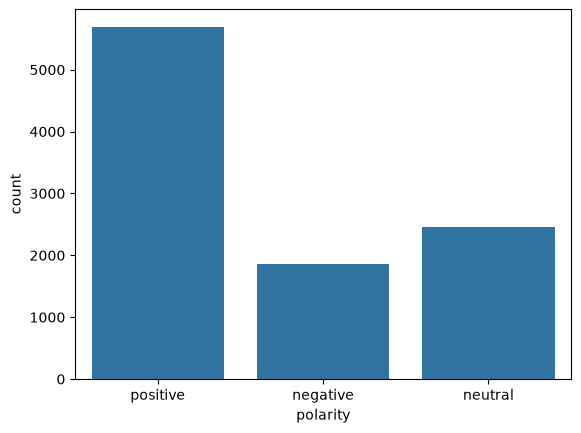

In [16]:
sns.countplot(data=clean_df,x='polarity') 

# Tokenizing & Train Test Split

In [17]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

I0000 00:00:1784178629.244379   40926 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1784178629.646425   40926 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1784178630.823590   40926 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [ ]:
# Pisahkan data menjadi fitur (tweet) dan label (sentimen)
X = clean_df['text_akhir']
y = clean_df['polarity']
 
max_features = 2500
tokenizer = Tokenizer(num_words=max_features, split=' ')
tokenizer.fit_on_texts(X.values)
X = tokenizer.texts_to_sequences(X.values)
X = pad_sequences(X)

# Label encoding
labelencoder = LabelEncoder()
integer_encoded = labelencoder.fit_transform(y)
y = to_categorical(integer_encoded)

# Menentukan jumlah kelas
num_classes = y.shape[1]

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# Modelling

In [42]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional, GlobalMaxPool1D



In [40]:
max_len = X.shape[1] 

# Jumlah kelas (dalam kasusmu ini nilainya akan otomatis jadi 3 jika polarity-nya Negatif/Netral/Positif)
num_classes = y.shape[1]

In [47]:
model = Sequential([
    # input_dim diisi max_features (2500). input_length diisi max_len dari data asli.
    Embedding(input_dim=max_features, output_dim=64, input_length=max_len),
    
    # Cukup 1 layer LSTM saja agar tidak overfit. 
    # Ditambah Dropout di dalam LSTM (dropout & recurrent_dropout) untuk regulerisasi.
    Bidirectional(LSTM(32, return_sequences=True, dropout=0.2, recurrent_dropout=0.2)),
    
    # Menggunakan GlobalMaxPool1D alih-alih Flatten. 
    # Ini jauh lebih aman dari overfit karena hanya mengambil fitur paling penting dari teks.
    GlobalMaxPool1D(),
    
    # Layer Dense dikurangi agar model tidak terlalu kompleks
    Dense(32, activation='relu'),
    Dropout(0.4), # Menaikkan dropout ke 0.4 untuk mengerem overfit
    
    # Layer output dinamis sesuai jumlah kelas unik dari labelencoder kamu
    Dense(num_classes, activation='softmax') 
])

In [48]:
class MyCallback(tf.keras.callbacks.Callback):
    def __init__(self, max_gap=0.10, min_val_acc=0.70):
        super(MyCallback, self).__init__()
        self.max_gap = max_gap       # Batas maksimal selisih (10%)
        self.min_val_acc = min_val_acc # Model harus menyentuh batas minimal akurasi dulu sebelum dicek gap-nya
        
    def on_epoch_end(self, epoch, logs={}):
        acc = logs.get('accuracy', 0)
        val_acc = logs.get('val_accuracy', 0)
        
        # 1. Kondisi Sukses: Dua-duanya di atas 85% (Target awalmu)
        if acc > 0.85 and val_acc > 0.85:
            print(f"\n[SUCCESS] Reached target! Train Acc: {acc:.4f}, Val Acc: {val_acc:.4f}. Stopping training.")
            self.model.stop_training = True
            return
            
        # 2. Kondisi Overfit: Gap makin lebar & Val Acc stuck
        gap = acc - val_acc
        if val_acc > self.min_val_acc and gap > self.max_gap:
            print(f"\n[WARNING] Overfitting detected! Gap too high ({gap:.4f}).")
            print(f"Train Acc: {acc:.4f} vs Val Acc: {val_acc:.4f}. Stopping training to prevent worse overfit.")
            self.model.stop_training = True

# Panggil callback-nya
callbacks = MyCallback(max_gap=0.10, min_val_acc=0.70)

In [49]:
# Compile model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [50]:
history = model.fit(X_train, y_train, epochs = 100, callbacks = ([callbacks]), validation_split=0.2)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 18s 78ms/step - accuracy: 0.6045 - loss: 0.8980 - val_accuracy: 0.7337 - val_loss: 0.6348
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 16s 78ms/step - accuracy: 0.7911 - loss: 0.5088 - val_accuracy: 0.8100 - val_loss: 0.4471
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 16s 78ms/step - accuracy: 0.8642 - loss: 0.3491 - val_accuracy: 0.8244 - val_loss: 0.4330
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 15s 77ms/step - accuracy: 0.8997 - loss: 0.2690 - val_accuracy: 0.8350 - val_loss: 0.4266
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 15s 77ms/step - accuracy: 0.9234 - loss: 0.2237 - val_accuracy: 0.8462 - val_loss: 0.4657
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.9353 - loss: 0.1834
[WARNING] Overfitting detected! Gap too high (0.1153).
Train Acc: 0.9353 vs Val Acc: 0.8200. Stopping training to prevent worse overfit.
200/200 ━━━━━━━━━━━━━━━━━━━━ 15s 77ms/step - accuracy: 0.9353 - loss: 0.1834 - val_accuracy: 0.8200 - val_loss: 0.5021


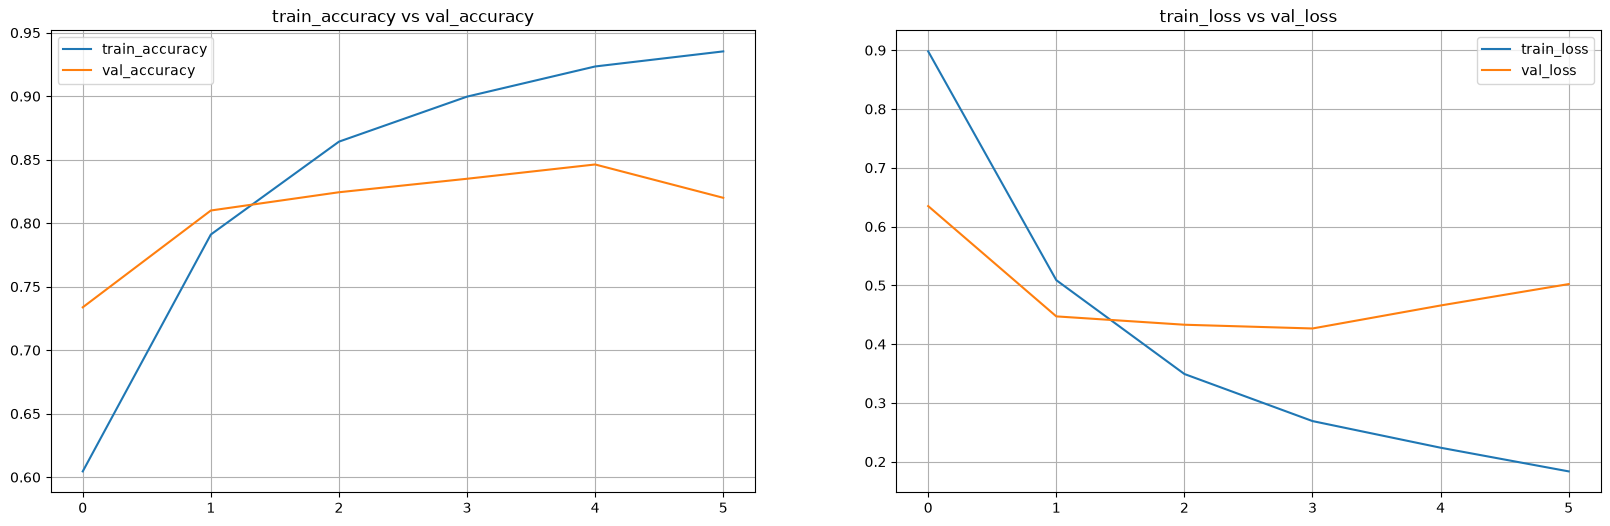

In [51]:
fig, axes = plt.subplots(1,2, figsize=[20,6])
sns.lineplot(data=history.history['accuracy'], ax=axes[0], label='train_accuracy')
sns.lineplot(data=history.history['val_accuracy'], ax=axes[0], label='val_accuracy')
axes[0].set_title('train_accuracy vs val_accuracy')


sns.lineplot(data=history.history['loss'], ax=axes[1], label='train_loss')
sns.lineplot(data=history.history['val_loss'], ax=axes[1], label='val_loss')
axes[1].set_title('train_loss vs val_loss')


axes[0].grid(True)
axes[1].grid(True)
plt.show() 

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step


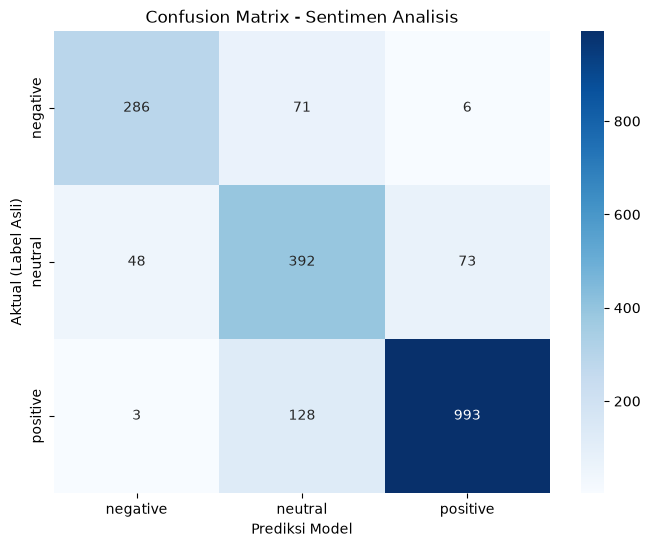

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

    negative       0.85      0.79      0.82       363
     neutral       0.66      0.76      0.71       513
    positive       0.93      0.88      0.90      1124

    accuracy                           0.84      2000
   macro avg       0.81      0.81      0.81      2000
weighted avg       0.84      0.84      0.84      2000



In [55]:
y_pred_probs = model.predict(X_test)

y_pred_labels = np.argmax(y_pred_probs, axis=1)
y_true_labels = np.argmax(y_test, axis=1)

class_names = list(labelencoder.classes_)

cm = confusion_matrix(y_true_labels, y_pred_labels)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, 
    annot=True,          # Menampilkan angka di dalam kotak
    fmt='d',             # Format angka sebagai integer (desimal)
    cmap='Blues',        # Warna gradasi biru
    xticklabels=class_names, 
    yticklabels=class_names
)
plt.title('Confusion Matrix - Sentimen Analisis')
plt.ylabel('Aktual (Label Asli)')
plt.xlabel('Prediksi Model')
plt.show()

print("=== CLASSIFICATION REPORT ===")
report = classification_report(y_true_labels, y_pred_labels, target_names=class_names)
print(report)


In [ ]:
model.save('model_LSTM.h5')